In [2]:
import yfinance as yf # A python wrapper around Yahoo Finance’s API
# This gives us stock info, company info, etc.

ticker = yf.Ticker("AAPL") # A ticker is a data container.
# It holds all the structured data Yahoo Finance provides for Apple 

print("Current Price:", ticker.info["currentPrice"])
print("Market Cap:", ticker.info["marketCap"])
print("P/E Ratio:", ticker.info["forwardPE"])
print("Dividend Yield:", ticker.info["dividendYield"])



Current Price: 297.01
Market Cap: 4362291642368
P/E Ratio: 30.936642
Dividend Yield: 0.36


In [6]:
import pandas as pd

tickers = ["AAPL", "MSFT", "GOOGL"]  # later replace with scraped list
data = []

for t in tickers:
    info = yf.Ticker(t).info
    data.append([
        t,
        info.get("currentPrice"),
        info.get("marketCap"),
        info.get("forwardPE"),
        info.get("dividendYield")
    ])

df = pd.DataFrame(data, columns=["Ticker", "Price", "Market Cap", "P/E", "Dividend Yield"])
df


,Ticker,Price,Market Cap,P/E,Dividend Yield
0,AAPL,297.01,4362291642368,30.936642,0.36
1,MSFT,367.34,2728761229312,18.988003,0.99
2,GOOGL,349.68,4266995482624,24.121851,0.25


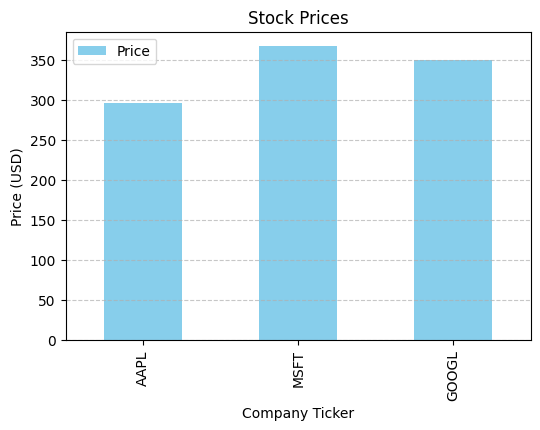

In [5]:
import matplotlib.pyplot as plt

# Bar chart
ax = df.plot(
    x="Ticker",
    y="Price",
    kind="bar",
    figsize=(6,4),
    color="skyblue",
    title="Stock Prices"
)

# Axis labels
ax.set_xlabel("Company Ticker")
ax.set_ylabel("Price (USD)")

# Gridlines for readability
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

plt.show()



In [7]:
import yfinance as yf

ticker = yf.Ticker("AAPL")
hist = ticker.history(period="6mo")  # the last 6 months
print(hist.head())


                                 Open        High         Low       Close  \
Date                                                                        
2025-12-23 00:00:00-05:00  270.337749  271.994674  269.060124  271.854919   
2025-12-24 00:00:00-05:00  271.834940  274.919206  271.695216  273.302216   
2025-12-26 00:00:00-05:00  273.651606  274.859353  272.353998  272.893005   
2025-12-29 00:00:00-05:00  272.184327  273.851213  271.844961  273.252350   
2025-12-30 00:00:00-05:00  272.304059  273.571693  271.775043  272.573547   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-12-23 00:00:00-05:00  29642000        0.0           0.0  
2025-12-24 00:00:00-05:00  17910600        0.0           0.0  
2025-12-26 00:00:00-05:00  21521800        0.0           0.0  
2025-12-29 00:00:00-05:00  23715200        0.0           0.0  
2025-12-30 00:00:00-05:00  22139600        0.0           0.0  


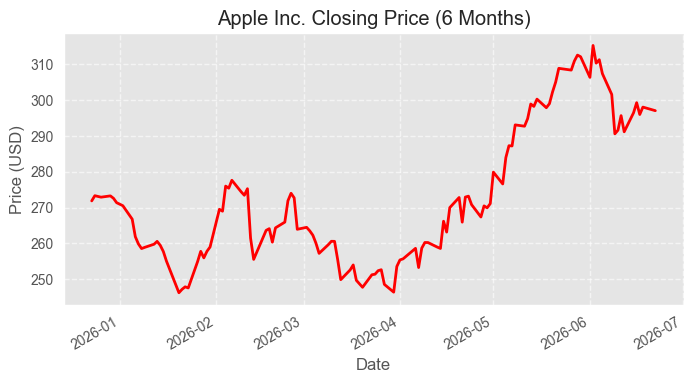

In [11]:
import matplotlib.pyplot as plt

# Use a built-in style with a subtle background
plt.style.use("ggplot")   # options: "ggplot", "seaborn-v0_8", "fivethirtyeight"

ax = hist["Close"].plot(
    title="Apple Inc. Closing Price (6 Months)",
    figsize=(8,4),
    color="red",      # line color set to red
    linewidth=2
)

ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.grid(True, linestyle="--", alpha=0.6)

plt.show()





In [22]:
import yfinance as yf

tickers = ["AAPL", "MSFT"]
hist_data = {}

for t in tickers:
    hist_data[t] = yf.Ticker(t).history(period="6mo")["Close"]

# Combine into one DataFrame
import pandas as pd
df_hist = pd.DataFrame(hist_data)
print(df_hist.head())



                                 AAPL        MSFT
Date                                             
2025-12-23 00:00:00-05:00  271.854919  484.691559
2025-12-24 00:00:00-05:00  273.302216  485.856323
2025-12-26 00:00:00-05:00  272.892975  485.547729
2025-12-29 00:00:00-05:00  273.252350  484.940430
2025-12-30 00:00:00-05:00  272.573578  485.318756


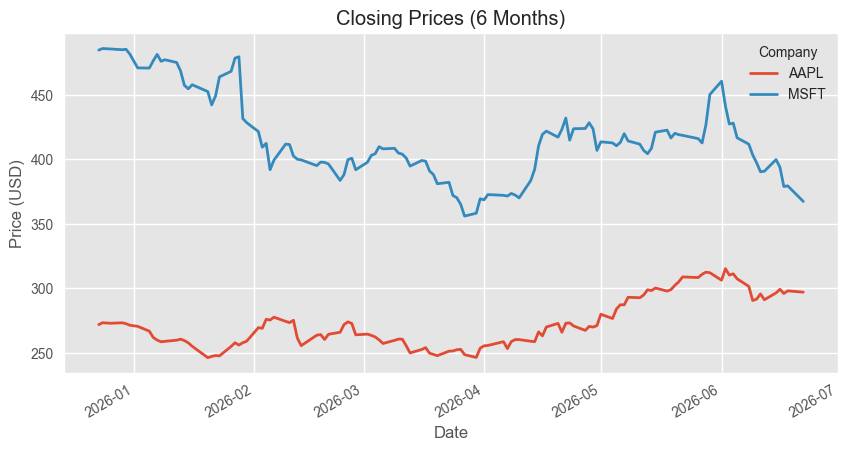

In [23]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

df_hist.plot(figsize=(10,5), linewidth=2)
plt.title("Closing Prices (6 Months)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(title="Company")
plt.show()


In [24]:
returns = df_hist.pct_change().dropna()
print(returns.head())



                               AAPL      MSFT
Date                                         
2025-12-24 00:00:00-05:00  0.005324  0.002403
2025-12-26 00:00:00-05:00 -0.001497 -0.000635
2025-12-29 00:00:00-05:00  0.001317 -0.001251
2025-12-30 00:00:00-05:00 -0.002484  0.000780
2025-12-31 00:00:00-05:00 -0.004468 -0.007918


In [25]:
from scipy import stats

apple_returns = returns["AAPL"]
msft_returns = returns["MSFT"]

t_stat, p_val = stats.ttest_ind(apple_returns, msft_returns, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_val)


t-statistic: 1.261864504541041
p-value: 0.20832355526144533


A two-sample t-test comparing Apple and Microsoft’s daily returns over the past 6 months yielded a t-statistic of 1.26 and a p-value of 0.21. Since p > 0.05, we conclude there is no statistically significant difference in mean returns between the two companies.

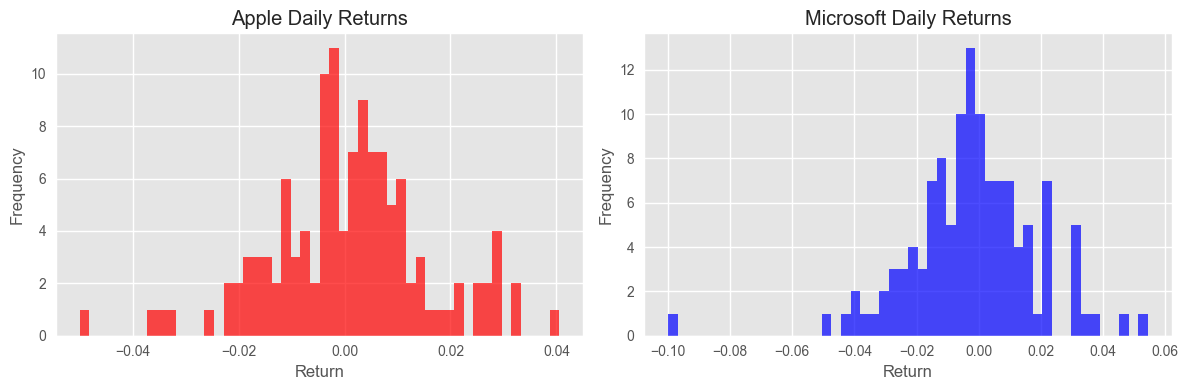

In [19]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Apple returns
returns["AAPL"].hist(bins=50, ax=axes[0], color="red", alpha=0.7)
axes[0].set_title("Apple Daily Returns")
axes[0].set_xlabel("Return")
axes[0].set_ylabel("Frequency")

# Microsoft returns
returns["MSFT"].hist(bins=50, ax=axes[1], color="blue", alpha=0.7)
axes[1].set_title("Microsoft Daily Returns")
axes[1].set_xlabel("Return")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [20]:
print("Apple volatility:", returns["AAPL"].std())
print("Microsoft volatility:", returns["MSFT"].std())


Apple volatility: 0.014969656354579865
Microsoft volatility: 0.02046052592230244


In [21]:
print(returns.corr())


           AAPL      MSFT     GOOGL
AAPL   1.000000  0.121264  0.260912
MSFT   0.121264  1.000000  0.140918
GOOGL  0.260912  0.140918  1.000000


Microsoft’s daily returns fluctuate more than Apple’s — it’s the riskier stock in this 6‑month window.
Apple shows lower volatility, meaning steadier returns, but that doesn’t necessarily mean higher profitability.

In finance terms: volatility = risk. Investors often balance high‑volatility stocks (potentially higher reward) with low‑volatility ones (stability).

In [26]:
import statsmodels.api as sm

# Independent variable (Microsoft returns)
X = msft_returns
X = sm.add_constant(X)  # adds intercept

# Dependent variable (Apple returns)
y = apple_returns

# Fit regression model
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.791
Date:                Tue, 23 Jun 2026   Prob (F-statistic):              0.183
Time:                        05:02:55   Log-Likelihood:                 340.91
No. Observations:                 122   AIC:                            -677.8
Df Residuals:                     120   BIC:                            -672.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.001      0.751      0.4

The relationship between Apple and Microsoft returns is positive but weak.

The low R² means Apple’s returns are largely driven by other factors, not Microsoft.

Since the p-value > 0.05, we cannot conclude that Microsoft’s returns significantly predict Apple’s returns.

Apple and Microsoft move together at times, but Microsoft’s returns are not a reliable predictor of Apple’s daily performance.

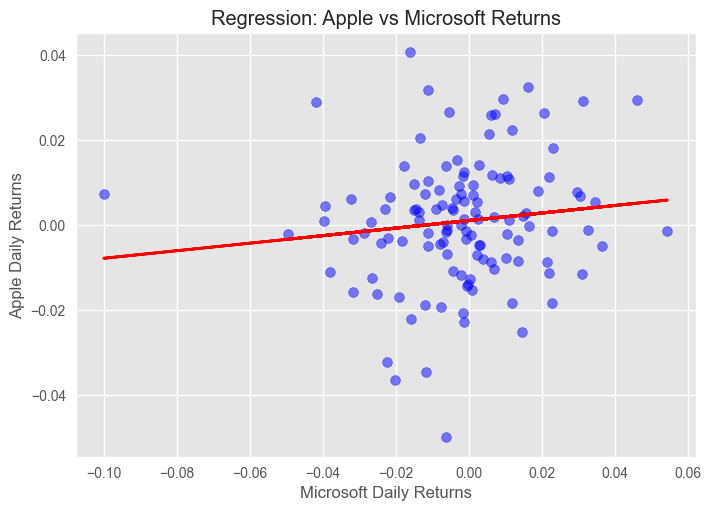

In [27]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

plt.scatter(msft_returns, apple_returns, alpha=0.5, color="blue")
plt.xlabel("Microsoft Daily Returns")
plt.ylabel("Apple Daily Returns")
plt.title("Regression: Apple vs Microsoft Returns")

# Regression line
predicted = model.predict(X)
plt.plot(msft_returns, predicted, color="red", linewidth=2)

plt.show()
